# RAG + Flan-T5 for MedMCQA

Do the below otherwise memory balloons (i think torch is to blame)

In [ ]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

Installs (imports come when needed because sometimes i rerun code but not the whole notebook)

In [ ]:
!pip install peft accelerate sentencepiece faiss-gpu-cu12 bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 35.2 MB/s eta 0:00:00


## Build FAISS Index

MedCPT is a semantic retriever, which is better than BM25 (lexical) but it takes a bit longer

In [ ]:
import torch
import numpy as np
import faiss
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

# load encoders (mcpt semantic) https://huggingface.co/ncbi/MedCPT-Query-Encoder
query_tokenizer  = AutoTokenizer.from_pretrained("ncbi/MedCPT-Query-Encoder")
query_encoder    = AutoModel.from_pretrained("ncbi/MedCPT-Query-Encoder").to("cuda") # move to gpu

article_tokenizer = AutoTokenizer.from_pretrained("ncbi/MedCPT-Article-Encoder")
article_encoder   = AutoModel.from_pretrained("ncbi/MedCPT-Article-Encoder").to("cuda")

# no tran jst eval
query_encoder.eval()
article_encoder.eval()

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
def encode_queries(queries, batch_size=32, max_length=64):
    # uses MedCPT to encode queries from question to vector space
    all_embs = []
    for i in range(0, len(queries), batch_size):
        batch = queries[i:i+batch_size] # batch the queries
        with torch.no_grad(): # tokenize the query and truncate if too long
        encoded = query_tokenizer(
            batch, truncation=True, padding=True,
            max_length=max_length, return_tensors="pt"
        ).to("cuda")
        emb = query_encoder(**encoded).last_hidden_state[:, 0, :]  # get the vector embedding https://huggingface.co/ncbi/MedCPT-Query-Encoder
        all_embs.append(emb.cpu().numpy()) # want numpy array
    return np.vstack(all_embs)

In [ ]:
def build_faiss_index(corpus_chunks, batch_size=512):
    # builds the FAISS index given chunks (100 words)
    print(f"Encoding {len(corpus_chunks):,} chunks.")
    embeddings = []

    for i in tqdm(range(0, len(corpus_chunks), batch_size)):
        batch = corpus_chunks[i:i+batch_size]
        with torch.no_grad(), torch.cuda.amp.autocast(True):
            encoded = article_tokenizer(
                batch,
                truncation=True, # truncate if too long but want to pad so we have same size everywhee
                padding=True,
                max_length=512, # should be more than enough
                return_tensors="pt" # cast to torch
            ).to("cuda")
            emb = article_encoder(**encoded).last_hidden_state[:, 0, :]
            embeddings.append(emb.cpu().float().numpy())  # cast back to float32 for FAISS

    embeddings = np.vstack(embeddings).astype("float32")
    faiss.normalize_L2(embeddings) # just make sure the l2 norm is equal to 1 (because faiss doesnt use cosine similarity)

    dim   = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim) # this is the search (inner product) https://github.com/facebookresearch/faiss/wiki/Faiss-indexes
    index.add(embeddings)

    print(f"Index built: {index.ntotal:,} vectors, dim={dim}")
    return index

Now we load the data from MedRAG (Wikipedia is HUGE so need to stream it)

In [ ]:
print("Loading Textbooks")
textbooks = load_dataset("MedRAG/textbooks", split="train") # use all

print("Streaming Wikipedia")
wikipedia = load_dataset("MedRAG/wikipedia", split="train", streaming=True) # need to stream (40GB no space in mem)

corpus_chunks = []
MIN_CHUNK_LEN = 100 # num words

textbook_tot, textbook_kept = 0, 0
from tqdm import tqdm
for ex in tqdm(textbooks):
    textbook_tot += 1
    if len(ex["content"]) >= MIN_CHUNK_LEN: # we just cut it off at 100 words (ex[content] is a string)
        corpus_chunks.append(ex["content"])
        textbook_kept += 1

wiki_total, wiki_kept = 0, 0
wiki_count = 0
for ex in tqdm(wikipedia, total=150000): # max 150k wikipedia (streaming is random from what i've seen)
    wiki_total += 1
    if len(ex["content"]) >= MIN_CHUNK_LEN: # again cut off at 100 words, don;t care about if we cut off mid sentence really
        corpus_chunks.append(ex["content"])
        wiki_kept += 1
    wiki_count += 1
    if wiki_count >= 150000:
        break

print(f"Textbooks: {textbook_kept:,} / {textbook_tot:,} kept")
print(f"Wikipedia: {wiki_kept:,} / {wiki_total:,} kept")
print(f"Total chunks: {len(corpus_chunks):,}")

Loading Textbooks


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

chunk/Anatomy_Gray.jsonl:   0%|          | 0.00/5.19M [00:00<?, ?B/s]

chunk/First_Aid_Step1.jsonl:   0%|          | 0.00/1.60M [00:00<?, ?B/s]

...

Streaming Wikipedia


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/646 [00:00<?, ?it/s]

100%|█████████▉| 149999/150000 [00:08<00:00, 17355.43it/s]

Textbooks: 125,180 / 125,847 kept
Wikipedia: 146,333 / 150,000 kept
Total chunks: 271,513


Below is copy paste of [this](https://huggingface.co/datasets/MedRAG/statpearls#direct-use)

In [ ]:
# https://huggingface.co/datasets/MedRAG/statpearls#direct-use
!git clone https://github.com/Teddy-XiongGZ/MedRAG.git
!cd MedRAG

!wget https://ftp.ncbi.nlm.nih.gov/pub/litarch/3d/12/statpearls_NBK430685.tar.gz \
      -P ./corpus/statpearls

!tar -xzvf ./corpus/statpearls/statpearls_NBK430685.tar.gz \
           -C ./corpus/statpearls

!python MedRAG/src/data/statpearls.py

Streaming output truncated to the last 5000 lines.
statpearls_NBK430685/article-36013.nxml
statpearls_NBK430685/Image__4__final.jpg
statpearls_NBK430685/article-148093.nxml
statpearls_NBK430685/Sebaceous__Adenoma.jpg
statpearls_NBK430685/PH__Enzyme__deficiency__slide.jpg
statpearls_NBK430685/article-149119.nxml
statpearls_NBK430685/article-19390.nxml
statpearls_NBK430685/Gray334.jpg
statpearls_NBK430685/article-24902.nxml
statpearls_NBK430685/disconnection__vpshunt.jpg
statpearls_NBK430685/article-218.nxml
statpearls_NBK430685/article-24256.nxml
statpearls_NBK430685/article-18092.nxml
statpearls_NBK430685/impetigo.jpg
statpearls_NBK430685/Human__Skin__2.jpg
statpearls_NBK430685/STA.jpg
statpearls_NBK430685/article-18403.nxml
statpearls_NBK430685/article-28881.nxml
statpearls_NBK430685/article-28426.nxml
statpearls_NBK430685/article-29723.nxml
statpearls_NBK430685/free__air.jpg
statpearls_NBK430685/article-23348.nxml
statpearls_NBK430685/article-24487.nxml
statpearls_NBK430685/article-2

Now we combine StatPearl with textbooks and Wikipedia to get the full corpus (should be around 600k chunks). Super small compared to the full MedRAG

In [ ]:
import json

statpearls_chunks = []
chunk_dir = "./corpus/statpearls/chunk" # we want to chunk the passages so our contexts aren't too long

for fname in sorted(os.listdir(chunk_dir)):
    fpath = os.path.join(chunk_dir, fname)
    with open(fpath) as f:
        for line in f:
            line = line.strip()
            if line:
                data = json.loads(line)
                if len(data["content"]) >= MIN_CHUNK_LEN: # literally just cut it off whenever
                    statpearls_chunks.append(data["content"])

print(f"StatPearls chunks: {len(statpearls_chunks):,}")
corpus_chunks.extend(statpearls_chunks) # add to the corpus
print(f"Total corpus: {len(corpus_chunks):,}")

StatPearls chunks: 344,310
Total corpus: 615,823


The below 3 are just for me. If you're building the FAISS index, you do below. If it has already been built, you'd do the 3rd. The 2nd is a debug but it works now

So the cell below is what you'd run if running everything at once (colab run all)

In [ ]:
index = build_faiss_index(corpus_chunks)
faiss.write_index(index, "medcpt_index.faiss")

# verify the file
saved = faiss.read_index("medcpt_index.faiss")
assert saved.ntotal == index.ntotal, "Save failed — vector counts don't match"
print("File size after save:", os.path.getsize("medcpt_index.faiss"))
print(f"Index saved correctly: {saved.ntotal:,} vectors")

This one here was to check whether the index would save correctly. Previously wasn't saving properly and I was getting errors. Turns out you have to save in drive and can't save and download to desktop

In [ ]:
from google.colab import drive
import faiss
drive.mount('/content/drive')
faiss.write_index(index, "/content/drive/MyDrive/medcpt_index.faiss")
saved = faiss.read_index("/content/drive/MyDrive/medcpt_index.faiss")
assert saved.ntotal == index.ntotal, f"Save failed: {saved.ntotal} != {index.ntotal}"
print(f"Index saved correctly: {saved.ntotal:,} vectors")

If index is already in drive, run this after building the rest of the corpus (textbooks, wikipedia, statpearsl). Since we need corpus_chunks

In [ ]:
from google.colab import drive
import faiss
drive.mount('/content/drive')
index = faiss.read_index("/content/drive/MyDrive/medcpt_index.faiss")

Mounted at /content/drive


Super simple retrieval function

In [ ]:
def retrieve(query, k=3):
    query_emb = encode_queries([query]).astype("float32") # encode question
    faiss.normalize_L2(query_emb) # normalize (for inner product, recall no cosine similaryty)
    scores, indices = index.search(query_emb, k) # search through the FAISS index (bottlneck sadly)
    docs = [corpus_chunks[i] for i in indices[0]] # get the top k scores and contexts
    return docs, scores[0].tolist()

## Load Dataset and Model

This is just MedMCQA. We need to do some work so that it and USMLE can have the exact same format for passing it into the model

In [ ]:
from datasets import load_dataset as ld

medmcqa = ld("openlifescienceai/medmcqa")

# convert raw fields to a consistent format (in this case Q, options, answer)
def convert_example(ex):
    return {
        "question": ex["question"], # question
        "options": { # individual options
            "A": ex["opa"],
            "B": ex["opb"],
            "C": ex["opc"],
            "D": ex["opd"],
        },
        "answer_idx": ["A", "B", "C", "D"][ex["cop"]] # answer is an int 0-3 so we map to a letter A-D (maybe matters?)
    }

full = medmcqa["train"].shuffle(seed=17).map(convert_example)
train_dataset = full.select(range(15000)) # want to have this not take 20 hours to train
test_dataset  = full.select(range(15000, 18000)) # we shuffle so this is random (shoud be random anywa)

val_dataset   = medmcqa["validation"].map(convert_example) # use full validation set since not that big

print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/85.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/936k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.48M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/182822 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6150 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4183 [00:00<?, ? examples/s]

Map:   0%|          | 0/182822 [00:00<?, ? examples/s]

Map:   0%|          | 0/4183 [00:00<?, ? examples/s]

Train: 15000
Val:   4183
Test:  3000


Now USMLE

In [ ]:
usmle = load_dataset("GBaker/MedQA-USMLE-4-options", split="train")

def convert_usmle(ex): # convert in the exact same wa y as abive (convert_examle), problem is USMLE has diff format (coilumn names)
    return {
        "id": f"usmle_{ex['answer_idx']}_{hash(ex['question']) % 10**8}",
        "question": ex["question"],
        "options": ex["options"],  # already a dict
        "answer_idx": ex["answer_idx"]
    }

usmle_converted = usmle.map(convert_usmle)
print(usmle_converted[0])

README.md:   0%|          | 0.00/654 [00:00<?, ?B/s]

phrases_no_exclude_train.jsonl:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

phrases_no_exclude_test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1273 [00:00<?, ? examples/s]

Map:   0%|          | 0/10178 [00:00<?, ? examples/s]

{'question': 'A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?', 'answer': 'Nitrofurantoin', 'options': {'A': 'Ampicillin', 'B': 'Ceftriaxone', 'C': 'Doxycycline', 'D': 'Nitrofurantoin'}, 'meta_info': 'step2&3', 'answer_idx': 'D', 'metamap_phrases': ['23 year old pregnant woman', 'weeks presents', 'burning', 'urination', 'states', 'started 1 day', 'worsening', 'drinking', 'water', 'taking cranberry extract', 'feels well', 'followed by', 'doctor', 'pregnancy', '

Huge issue is data imbalance. If model can decrease loss by selecting one label it will do that (if data is imbalanced this is much more likely), so training data is set to have same number of each label

In [ ]:
from datasets import concatenate_datasets
from collections import defaultdict
from datasets import Dataset
import random
random.seed(17)

combined = concatenate_datasets([train_dataset, usmle_converted]) # finally build our train dataset

# rebalance the combined set (massive issue prior to this)
buckets = defaultdict(list)
for ex in combined:
    buckets[ex["answer_idx"]].append(ex)

min_count = min(len(v) for v in buckets.values())
print(f"Balancing to {min_count} per label to {min_count*4} total")

balanced = []
for letter in ["A", "B", "C", "D"]:
    balanced.extend(random.sample(buckets[letter], min_count))

random.shuffle(balanced) # random seed is set so shouldn't change on 1st pass
train_dataset = Dataset.from_list(balanced)

Model is t5-flan-xl and we're going to 4-bit uantize since it's huge. The other option would be to use a smaller model and use bf16. This makes it faster to train (no dequantizing) but can't get expressivity of huge model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, BitsAndBytesConfig
import torch

model_name = "google/flan-t5-xl"
tokenizer  = AutoTokenizer.from_pretrained(model_name)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # dequantizes to bf16
    bnb_4bit_quant_type="nf4", # quantizes to fp4
    bnb_4bit_use_double_quant=True, # from https://discuss.huggingface.co/t/is-this-needed-bnb-4bit-use-double-quant-true/50616 mentions why to use (trouble with mem)
)

# super simple, we just use the bitsandbytes config! auto maps to GPU if cuda available otherwise CPU
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)
model.gradient_checkpointing_enable() # only store subset of activations (saves memory)

# just check to make sure everything is good (should see cuda and 1.7B parameters)
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print(f"Device: {next(model.parameters()).device}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Params: 1742.5M
Device: cuda:0


## Prompting & Scoring

Below is the prompt to be used for all MC questions. Probmlem is probably prompt engineering. Maybe could've had better prompt

In [ ]:
def build_mc_prompt(question, options, context=None):
    # builds the multiple-choice prompt... RAG is optional (context)

    # concat the options together
    choices_text = "\n".join([
        f"A. {options['A']}",
        f"B. {options['B']}",
        f"C. {options['C']}",
        f"D. {options['D']}",
    ])

    # optional
    ctx_block = f"Context:\n{context}\n\n" if context else ""

    # the full rpompt finally (again could be better but... )
    return (
        f"{ctx_block}"
        f"Question:\n{question}\n\n"
        f"Choices:\n{choices_text}\n\n"
        f"Answer with only the letter (A, B, C, or D):"
    )

In [ ]:
import torch
import re

# tokenize the four letter targets ONCE
LETTER_IDS = {
    letter: tokenizer(letter, add_special_tokens=False).input_ids[0]
    for letter in ["A", "B", "C", "D"]
}

def score_options(question, options, context=None):
    '''
    Scores the options given.
    So, for each option, will give a score and pick the best one.
    Using loss for this. Lower loss is better. Other option is accuracy but then need to evaluate full train AND val set.
    '''
    prompt   = build_mc_prompt(question, options, context)
    inputs   = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda") # inputs are the prompt but truncated... thus contexts sometimes cut off
    scores   = {}
    for letter in ["A", "B", "C", "D"]:
        target = f"{letter}. {options[letter]}"  # shows the letter AND the answee: ex: C. Vitamin A
        label_ids = tokenizer(target,
                              return_tensors="pt",
                              truncation=True,
                              max_length=32).input_ids.to("cuda")
        with torch.no_grad():
            loss = model(**inputs, labels=label_ids).loss.item()
        scores[letter] = -loss # using loss for score
    return max(scores, key=scores.get)

In [ ]:
from tqdm import tqdm

# simple evaluate function
def evaluate(dataset, mode="baseline", max_samples=None, contexts=None):
    # if using mode='rag', you MUST pass in contexts
    correct = 0
    subset  = dataset if max_samples is None else dataset.select(range(max_samples)) # use subset but if none specified use all

    for ex in tqdm(subset):
        q       = ex["question"]
        options = ex["options"]
        gold    = ex["answer_idx"] # correct answer

        if mode == "baseline":
            pred = score_options(q, options) # no RAG
        else:
            context = contexts[ex["id"]] # this is built up previously to speed up retrieval (at the cost of empory)
            pred    = score_options(q, options, context) # RAG

        if pred == gold: # trusting model to produce a valid output (ONE LETTER A B C or D)
            correct += 1

    return correct / len(subset)

## Fine-tuning with LoRA

Use LoRA. Should only be using about 1.5% of parameters. Papers say generally that range is good (0.5%-1.5%), but obviously I think the number matters more.

In [ ]:
from peft import LoraConfig, get_peft_model

# reason for below was kinda random
# just try to prevent collapse as much as possibl
lora_config = LoraConfig(
    r=32, # keeps more of the trainable params
    lora_alpha=64, # i've read conflicting evidence but essentially if alpha/r = 2, you double the adapter's effect, if 0.5 you half it. so i doubled it
    target_modules=["q", "v", "k", "o", "wi", "wo"], # https://huggingface.co/google/flan-t5-large/discussions/23 didn't have time to hyperparam tune so just took these modules
    lora_dropout=0.1, # an attempt to prevent overfitting ona. big model
    bias="none",
    task_type="SEQ_2_SEQ_LM" # task type
)

model = get_peft_model(model, lora_config) # apply lora (i shouldve use qlora with quantized but that's on me)
model.print_trainable_parameters()

trainable params: 48,758,784 || all params: 2,898,515,968 || trainable%: 1.6822


In [ ]:
# saves time later when doing formatting since we dont have ti search
def precompute_contexts(dataset, k=3, batch_size=256):
    questions = [ex["question"] for ex in dataset]
    ids       = [ex["id"] for ex in dataset]

    print(f"Encoding {len(questions):,} queries")
    all_embs = encode_queries(questions, batch_size=batch_size)
    faiss.normalize_L2(all_embs)

    print("Searching index")
    scores, indices = index.search(all_embs, k)  # only use one call to FAISS but with a batch instead of single item

    print("Building context map")
    contexts = {}
    for i, uid in tqdm(enumerate(ids)):
        docs = [corpus_chunks[idx] for idx in indices[i]]
        contexts[uid] = "\n\n".join(doc[:200] for doc in docs)

    return contexts

In [ ]:
print("Pre-retrieving train contexts")
train_contexts = precompute_contexts(train_dataset)

print("Pre-retrieving val contexts")
val_contexts = precompute_contexts(val_dataset.select(range(2000)))

print("Pre-retrieving test contexts")
test_contexts = precompute_contexts(test_dataset)

Pre-retrieving train contexts
Encoding 15,000 queries


/tmp/ipykernel_20040/3775072943.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


Searching index
Building context map
Pre-retrieving val contexts
Encoding 2,000 queries
Searching index
Building context map
Pre-retrieving test contexts
Encoding 3,000 queries
Searching index
Building context map


## Pre-training Baseline Scores

Run this before fine-tuning so we have a fair before/after comparison.

In [ ]:
# eval on full test set
EVAL_SAMPLES = len(test_dataset)

print("Evaluating baseline")
pre_baseline_acc = evaluate(test_dataset, mode="baseline", max_samples=EVAL_SAMPLES)
print(f"Pre-FT Baseline accuracy: {pre_baseline_acc:.3f}")

Evaluating baseline


100%|██████████| 3000/3000 [56:42<00:00,  1.13s/it]

Pre-FT Baseline accuracy: 0.282


In [ ]:
EVAL_SAMPLES = len(test_dataset)
print("\nEvaluating RAG (before fine-tuning)")
pre_rag_acc = evaluate(test_dataset, mode="rag", max_samples=EVAL_SAMPLES, contexts=test_contexts)
print(f"Pre-FT RAG accuracy: {pre_rag_acc:.3f}")


Evaluating RAG (before fine-tuning)


100%|██████████| 3000/3000 [56:57<00:00,  1.14s/it]

Pre-FT RAG accuracy: 0.322


In [ ]:
# load USMLE test set
usmle_test = load_dataset("GBaker/MedQA-USMLE-4-options", split="test")
usmle_test = usmle_test.map(convert_usmle)
print(f"USMLE test set: {len(usmle_test):,} examples")

# precompute contexts to imrpve speed
print("Pre-retrieving USMLE test contexts")
usmle_test_contexts = precompute_contexts(usmle_test.select(range(len(usmle_test))))

Map:   0%|          | 0/1273 [00:00<?, ? examples/s]

USMLE test set: 1,273 examples
Pre-retrieving USMLE test contexts...
Encoding 1,273 queries


/tmp/ipykernel_3743/3475681791.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


Searching index
Building context map


1273it [00:00, 243029.08it/s]


In [ ]:
print("Baseline (no RAG)")
usmle_pre_baseline = evaluate(usmle_test, mode="baseline", max_samples=len(usmle_test))

print("Baseline + RAG")
usmle_pre_rag = evaluate(usmle_test, mode="rag", max_samples=len(usmle_test), contexts=usmle_test_contexts)

Baseline (no RAG)


100%|██████████| 1273/1273 [24:44<00:00,  1.17s/it]


Baseline + RAG


100%|██████████| 1273/1273 [25:00<00:00,  1.18s/it]


In [ ]:
print(f"\nBaseline (no RAG): {usmle_pre_baseline:.3f}")
print(f"Baseline + RAG:    {usmle_pre_rag:.3f}")


Baseline (no RAG): 0.280
Baseline + RAG:    0.273


In [ ]:
def format_example(ex):
    """
    Returns (input_text, target_text) for fine-tuning.
    where target_text is a letter and input_text is the whole ptmo
    """
    idx = ex["id"]
    context = train_contexts.get(idx) or val_contexts.get(idx) # get the contexts depending on id
    input_text  = build_mc_prompt(ex["question"], ex["options"], context) # build a prompt
    target_text = ex["answer_idx"] # get the correct answer
    return input_text, target_text


def tokenize_fn(example):
    inp, tgt = format_example(example)

    # pass this into the model
    model_inputs = tokenizer(
        inp,
        truncation=True,
        padding="max_length",
        max_length=512
    )

    # max_length used so we don't generate too much (using 1 gives warnings)
    label_enc = tokenizer(
        tgt,
        truncation=True,
        padding="max_length",
        max_length=4
    )

    # mask padding in the labels otherwise they taek iver
    model_inputs["labels"] = [
        l if l != tokenizer.pad_token_id else -100
        for l in label_enc["input_ids"]
    ]

    return model_inputs

In [ ]:
print("Tokenizing train set")
train_tok = train_dataset.map(
    tokenize_fn,
    remove_columns=train_dataset.column_names # otherwise get errors that some columns are there when they shoukldn;t be
)

print("Tokenizing val set")
val_tok = val_dataset.select(range(2000)).map(  # val set is not that big but we slice because wtv
    tokenize_fn,
    remove_columns=val_dataset.column_names
)

print("Done.")

Tokenizing train set


Map:   0%|          | 0/22696 [00:00<?, ? examples/s]

Tokenizing val set


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Done.


In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, TrainerCallback

# collapse monitor is just here to make sure I see when the model is about to start slecting the same label
class CollapseMonitor(TrainerCallback):
    def on_evaluate(self, args, state, control, **kwargs):
        preds = {l: 0 for l in "ABCD"}
        for ex in val_dataset.select(range(200)):
            pred = score_options(ex["question"], ex["options"])
            preds[pred] += 1
        print(f"\nPrediction distribution: {preds}")

# super standard
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/rag_t5_checkpoints",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,   # effective batch = 8 (saves memory)
    per_device_eval_batch_size=4,
    learning_rate=1e-4, # generally used with lora (fewer params so higher lr)
    num_train_epochs=1, # 5 hours for just 1 so not doing more
    logging_strategy="steps", # as opposed to epoch
    logging_steps=300,
    save_strategy="steps",
    save_steps=300,
    save_total_limit=2, # keep saves in drive but not all of them
    eval_strategy="steps",
    eval_steps=300,
    bf16=True, # need to dequantize to bf16 whchi is an issue but oh well it's done
    load_best_model_at_end=True,
    label_smoothing_factor=0.1, # prevents collapse
    predict_with_generate=False,
    warmup_steps=400, # without this the model collapses pretty much instantly
    max_grad_norm=0.3, # we don't want the update to be too big
)

from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    callbacks=[CollapseMonitor()],
    data_collator=data_collator
)

trainer.train()

Step,Training Loss,Validation Loss
300,15.527410,2.821077
600,5.353547,2.217863
900,4.549573,2.175745
1200,4.503225,2.161341
1500,4.476569,2.172307
1800,4.470390,2.169934
2100,4.459753,2.152738
2400,4.455891,2.142826
2700,4.439386,2.142384



Prediction distribution: {'A': 35, 'B': 32, 'C': 54, 'D': 79}

Prediction distribution: {'A': 34, 'B': 46, 'C': 59, 'D': 61}

Prediction distribution: {'A': 36, 'B': 40, 'C': 64, 'D': 60}

Prediction distribution: {'A': 42, 'B': 52, 'C': 50, 'D': 56}

Prediction distribution: {'A': 35, 'B': 49, 'C': 58, 'D': 58}

Prediction distribution: {'A': 34, 'B': 50, 'C': 56, 'D': 60}

Prediction distribution: {'A': 41, 'B': 49, 'C': 48, 'D': 62}

Prediction distribution: {'A': 42, 'B': 50, 'C': 53, 'D': 55}

Prediction distribution: {'A': 42, 'B': 49, 'C': 54, 'D': 55}


TrainOutput(global_step=2837, training_loss=5.737268544016567, metrics={'train_runtime': 18460.1315, 'train_samples_per_second': 1.229, 'train_steps_per_second': 0.154, 'total_flos': 1.975029265984389e+17, 'train_loss': 5.737268544016567, 'epoch': 1.0})

Model saved but not training information so need to do it manually (results are above anyway i just wanted a graph rather than a table)

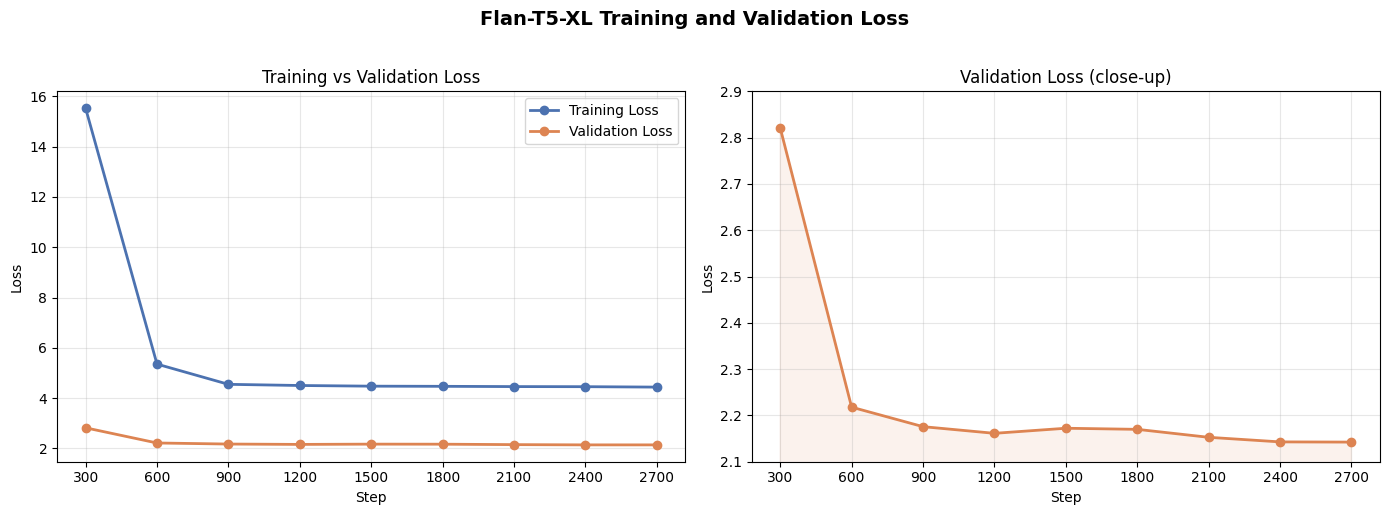

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

steps      = [300, 600, 900, 1200, 1500, 1800, 2100, 2400, 2700]
train_loss = [15.527410, 5.353547, 4.549573, 4.503225, 4.476569, 4.470390, 4.459753, 4.455891, 4.439386]
val_loss   = [2.821077, 2.217863, 2.175745, 2.161341, 2.172307, 2.169934, 2.152738, 2.142826, 2.142384]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Flan-T5-XL Training and Validation Loss", fontsize=14, fontweight="bold", y=1.02)

# both tigether
ax1 = axes[0]
ax1.plot(steps, train_loss, marker="o", linewidth=2, color="blue", label="Training Loss")
ax1.plot(steps, val_loss,   marker="o", linewidth=2, color="orange", label="Validation Loss")
ax1.set_title("Training vs Validation Loss")
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(300))

# val loss zoomed into
ax2 = axes[1]
ax2.plot(steps, val_loss, marker="o", linewidth=2, color="blue", label="Validation Loss")
ax2.fill_between(steps, val_loss, alpha=0.1, color="orange")
ax2.set_title("Validation Loss (close-up)")
ax2.set_xlabel("Step")
ax2.set_ylabel("Loss")
ax2.set_ylim(2.1, 2.9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(300))

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# save the model
model.save_pretrained("/content/drive/MyDrive/rag_t5_final")
tokenizer.save_pretrained("/content/drive/MyDrive/rag_t5_final")
print("Model saved.")

Model saved.


## Post-training Evaluation

In [ ]:
EVAL_SAMPLES = len(test_dataset)

print("Evaluating fine-tuned model + RAG")
post_rag_acc = evaluate(test_dataset, mode="rag", max_samples=EVAL_SAMPLES, contexts=test_contexts)

print("Evaluating fine-tuned model, no RAG")
post_baseline_acc = evaluate(test_dataset, mode="baseline", max_samples=EVAL_SAMPLES)

print(f"{'Method':<30} {'Accuracy':>10}")
# print(f"{'Pre-FT Baseline':<30} {pre_baseline_acc:>10.3f}")
# print(f"{'Pre-FT + RAG':<30} {pre_rag_acc:>10.3f}")
print(f"{'Post-FT Baseline':<30} {post_baseline_acc:>10.3f}")
print(f"{'Post-FT + RAG':<30} {post_rag_acc:>10.3f}")

Evaluating fine-tuned model + RAG


100%|██████████| 3000/3000 [1:01:38<00:00,  1.23s/it]


Evaluating fine-tuned model, no RAG


100%|██████████| 3000/3000 [1:01:48<00:00,  1.24s/it]


Method                           Accuracy
----------------------------------------
Post-FT Baseline                    0.236
Post-FT + RAG                       0.239


Had to reload model because colab runtime disconnected for no reason

In [ ]:
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-xl",
    quantization_config=bnb_config,
    device_map="auto"
)

model     = PeftModel.from_pretrained(base_model, "/content/drive/MyDrive/rag_t5_final")
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/rag_t5_final")
model.eval()
print("Model loaded.")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded.


USMLE after fine-tune

In [ ]:
print("Fine-tuned (no RAG)")
usmle_post_baseline = evaluate(usmle_test, mode="baseline", max_samples=len(usmle_test))

print("Fine-tuned + RAG")
usmle_post_rag = evaluate(usmle_test, mode="rag", max_samples=len(usmle_test), contexts=usmle_test_contexts)

Fine-tuned (no RAG)


100%|██████████| 1273/1273 [23:50<00:00,  1.12s/it]


Fine-tuned + RAG


100%|██████████| 1273/1273 [24:03<00:00,  1.13s/it]


In [ ]:
print(f"{'Fine-tuned (no RAG)':<30} {usmle_post_baseline:>10.3f}")
print(f"{'Fine-tuned + RAG':<30} {usmle_post_rag:>10.3f}")


Method                           Accuracy
----------------------------------------
Fine-tuned (no RAG)                 0.225
Fine-tuned + RAG                    0.227


## Inspect Predictions

Sample a few examples to see what the model is doing right and wrong.

In [ ]:
sample_idxs = random.sample(range(len(test_dataset)), 5)

for idx in sample_idxs:
    ex      = test_dataset[idx]
    q       = ex["question"]
    options = ex["options"]
    gold    = ex["answer_idx"]

    choices_text = "\n".join([
        f"A. {options['A']}",
        f"B. {options['B']}",
        f"C. {options['C']}",
        f"D. {options['D']}",
    ])

    # baseline prediction of Q
    baseline_pred = score_options(q, options)

    # RAG prediction of Q
    docs, scores = retrieve(q, k=3)
    context      = "\n\n".join(doc[:200] for doc in docs)
    rag_pred     = score_options(q, options, context)

    print("=" * 100)
    print(f"Example {idx}")
    print(f"\nQuestion:\n{q}")
    print(f"\nChoices:\n{choices_text}")
    print(f"\nGold: {gold}")
    print(f"Baseline pred: {baseline_pred}")
    print(f"RAG pred:      {rag_pred}")

    print("\nTop retrieved chunks:")
    for j, (doc, score) in enumerate(zip(docs, scores), 1):
        print(f"\n  [{j}] score={score:.2f}")
        print(f"  {doc[:300]}")
    print()

## Just checking

Below is just a acheck after to see if passing in the question AND options into the FAISS retrieval would have worked better (answer is yes) so I could see if maybe that was a problem

In [ ]:
!pip install peft
!pip install -U bitsandbytes>=0.46.1
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, BitsAndBytesConfig
import torch
from google.colab import drive
drive.mount('/content/drive')

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-xl",
    quantization_config=bnb_config,
    device_map="auto"
)

model     = PeftModel.from_pretrained(base_model, "/content/drive/MyDrive/rag_t5_final")
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/rag_t5_final")
model.eval()
print("Model loaded.")

Mounted at /content/drive


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded.


In [ ]:
def retrieve_with_options(question, options, k=3):
    full_query = f"{question} {' '.join(options[l] for l in 'ABCD')}" # build up the new query
    return retrieve(full_query, k=k) # retrieve

from tqdm import tqdm

def evaluate_with_options_rag(dataset, max_samples=None):
    correct = 0
    subset  = dataset if max_samples is None else dataset.select(range(max_samples))
    for ex in tqdm(subset):
        q, options, gold = ex["question"], ex["options"], ex["answer_idx"] # get the information to pass into the model as well as the gold anser
        docs, _  = retrieve_with_options(q, options, k=3) # get the contexts
        context  = "\n\n".join(doc[:200] for doc in docs)
        pred     = score_options(q, options, context)
        if pred == gold:
            correct += 1
    return correct / len(subset)

EVAL_SAMPLES = 100  # start with 100 to check quickly, then run full set

print("Evaluating with question+options RAG")
options_rag_acc = evaluate_with_options_rag(test_dataset, max_samples=EVAL_SAMPLES)

In [ ]:
print(f"{'Post-FT + RAG (q+options)':<30} {options_rag_acc:>10.3f}")


Method                           Accuracy
----------------------------------------
Post-FT + RAG (q+options)           0.290


In [ ]:
EVAL_SAMPLES = len(usmle_test)  # start with 100 to check quickly, then run full set

print("Evaluating with question+options RAG")
options_rag_acc = evaluate_with_options_rag(usmle_test, max_samples=EVAL_SAMPLES)

Evaluating with question+options RAG...


100%|██████████| 1273/1273 [28:38<00:00,  1.35s/it]


In [ ]:
print(f"{'Post-FT + RAG (q+options)':<30} {options_rag_acc:>10.3f}")


Method                           Accuracy
----------------------------------------
Post-FT + RAG (q+options)           0.228
